In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

RAW_DATA_DIR = "/kaggle/input/datasets/dhoogla/cicids2017"
WORK_DIR = "/kaggle/working"

PARQUET_FILES = [
    "Benign-Monday-no-metadata.parquet",
    "Botnet-Friday-no-metadata.parquet",
    "Bruteforce-Tuesday-no-metadata.parquet",
    "DDoS-Friday-no-metadata.parquet",
    "DoS-Wednesday-no-metadata.parquet",
    "Infiltration-Thursday-no-metadata.parquet",
    "Portscan-Friday-no-metadata.parquet",
    "WebAttacks-Thursday-no-metadata.parquet",
]

In [2]:
def infer_attack_category_from_filename(fname: str) -> str:
    base = os.path.basename(fname).lower()
    if "benign" in base:
        return "Normal"
    if "botnet" in base:
        return "Bot"
    if "bruteforce" in base:
        return "BruteForce"
    if "ddos" in base:
        return "DDoS"
    if "dos" in base:
        return "DoS"
    if "portscan" in base:
        return "PortScan"
    if "webattacks" in base:
        return "WebAttack"
    if "infiltration" in base:
        return "Infiltration"
    return "Unknown"

In [3]:
dfs = []
for fname in PARQUET_FILES:
    fpath = os.path.join(RAW_DATA_DIR, fname)
    df_part = pd.read_parquet(fpath)
    df_part["attack_category"] = infer_attack_category_from_filename(fname)
    dfs.append(df_part)

df_raw = pd.concat(dfs, ignore_index=True)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (2313810, 79)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_category
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,Normal


In [4]:
print("Raw DataFrame info:")
df_raw.info()

raw_memory_mb = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"\nApprox. raw memory usage: {raw_memory_mb:.2f} MB")

raw_missing = df_raw.isna().sum()
raw_missing[raw_missing > 0].sort_values(ascending=False)

Raw DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313810 entries, 0 to 2313809
Data columns (total 79 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  int32  
 6   Fwd Packet Length Max     int16  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int16  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              int32  
 19  Flow IAT Min              int32  
 20  Fwd 

Series([], dtype: int64)

In [5]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
df_raw[numeric_cols].describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Protocol,2313810.0,1.050673e+01,5.416040e+00,0.0,6.0,6.0,17.00,17.0
Flow Duration,2313810.0,1.807575e+07,3.640823e+07,-13.0,476.0,64783.0,5856947.75,119999998.0
Total Fwd Packets,2313810.0,1.108391e+01,8.291879e+02,1.0,2.0,2.0,6.00,219759.0
Total Backward Packets,2313810.0,1.255334e+01,1.103179e+03,0.0,1.0,2.0,5.00,291922.0
Fwd Packets Length Total,2313810.0,6.664045e+02,1.105009e+04,0.0,37.0,74.0,356.00,12900000.0


In [6]:
before_duplicates = len(df_raw)
df_no_dup = df_raw.drop_duplicates()
after_duplicates = len(df_no_dup)

print(f"Removed {before_duplicates - after_duplicates} duplicate rows "
      f"({(before_duplicates - after_duplicates) / before_duplicates:.4%})")

Removed 0 duplicate rows (0.0000%)


In [7]:
df_clean = df_no_dup.copy()

# Count NaN before
nan_before = df_clean.isna().sum().sum()

# Replace inf / -inf with NaN, then drop rows with any NaN
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_after_inf = df_clean.isna().sum().sum()

print(f"Total NaNs before replacing inf: {nan_before}")
print(f"Total NaNs after marking inf as NaN: {nan_after_inf}")

rows_before_nan_drop = len(df_clean)
df_clean = df_clean.dropna(axis=0)
rows_after_nan_drop = len(df_clean)

print(f"Dropped {rows_before_nan_drop - rows_after_nan_drop} rows with NaN "
      f"({(rows_before_nan_drop - rows_after_nan_drop) / rows_before_nan_drop:.4%})")

Total NaNs before replacing inf: 0
Total NaNs after marking inf as NaN: 0
Dropped 0 rows with NaN (0.0000%)


In [8]:
# Optional: restrict inf/NaN cleaning to numeric columns
# df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
# df_clean.dropna(subset=numeric_cols, inplace=True)

In [9]:
# Example sanity checks
print("Min/Max of Flow Duration:", df_clean["Flow Duration"].min(), df_clean["Flow Duration"].max())
print("Min/Max Flow Bytes/s:", df_clean["Flow Bytes/s"].min(), df_clean["Flow Bytes/s"].max())
print("Min/Max Flow Packets/s:", df_clean["Flow Packets/s"].min(), df_clean["Flow Packets/s"].max())

Min/Max of Flow Duration: -13 119999998
Min/Max Flow Bytes/s: -261000000.0 2071000000.0
Min/Max Flow Packets/s: -2000000.0 4000000.0


In [10]:
# Example clipping for clearly invalid durations (if present)
rows_before_clip = len(df_clean)
invalid_duration_mask = df_clean["Flow Duration"] <= 0

print("Rows with non-positive Flow Duration:", invalid_duration_mask.sum())

# If you want to drop them:
df_clean = df_clean[~invalid_duration_mask].copy()
rows_after_clip = len(df_clean)

print(f"Dropped {rows_before_clip - rows_after_clip} rows with non-positive Flow Duration")

Rows with non-positive Flow Duration: 88
Dropped 88 rows with non-positive Flow Duration


In [11]:
# Sample for unsupervised outlier analysis
IF_SAMPLE_SIZE = 200_000

if len(df_clean) > IF_SAMPLE_SIZE:
    df_if = df_clean.sample(IF_SAMPLE_SIZE, random_state=42)
else:
    df_if = df_clean.copy()

numeric_cols = df_if.select_dtypes(include=[np.number]).columns

X_if = df_if[numeric_cols].astype(np.float32)

iso = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iso.fit(X_if)
scores = iso.decision_function(X_if)
preds = iso.predict(X_if)  # -1 = outlier, 1 = inlier

df_if["if_score"] = scores
df_if["if_label"] = preds

df_if["if_label"].value_counts(normalize=True)

if_label
 1    0.8969
-1    0.1031
Name: proportion, dtype: float64

In [12]:
outlier_rate_by_attack = (
    df_if.groupby(["attack_category", "if_label"])
         .size()
         .unstack(fill_value=0)
)

outlier_rate_by_attack["outlier_ratio"] = (
    outlier_rate_by_attack.get(-1, 0) /
    outlier_rate_by_attack.sum(axis=1)
)

outlier_rate_by_attack

if_label,-1,1,outlier_ratio
attack_category,,,
Bot,1018,14123,0.067235
BruteForce,2217,31402,0.065945
DDoS,3718,15602,0.192443
DoS,8478,42047,0.167798
Infiltration,1122,16784,0.062661
Normal,2585,37223,0.064937
PortScan,633,9559,0.062108
WebAttack,849,12640,0.062940


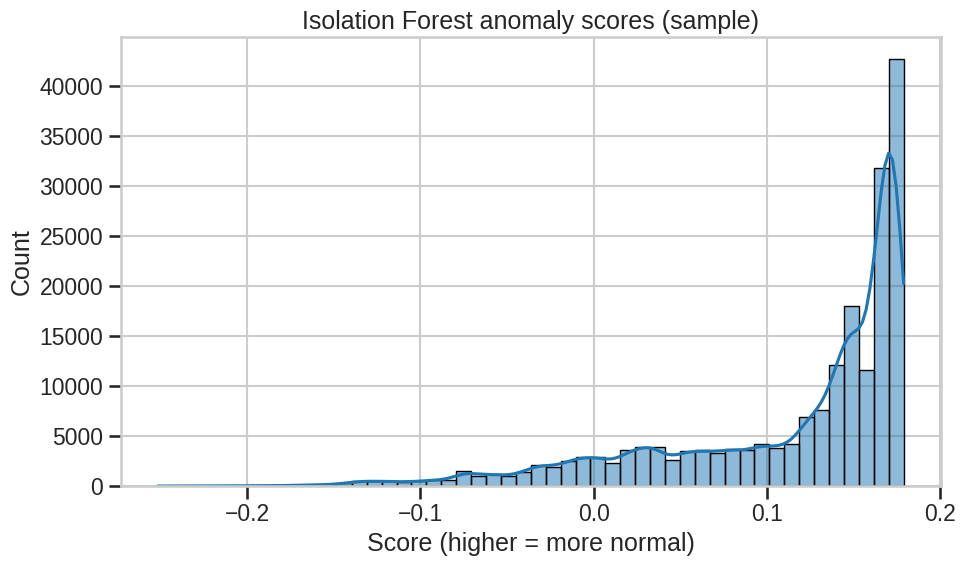

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_if["if_score"], bins=50, kde=True)
plt.title("Isolation Forest anomaly scores (sample)")
plt.xlabel("Score (higher = more normal)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("isolation_forest_scores_hist.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
def summarize_df(df: pd.DataFrame, name: str) -> pd.Series:
    n_rows = len(df)
    n_cols = df.shape[1]
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    n_duplicates = df.duplicated().sum()
    n_missing = df.isna().sum().sum()
    return pd.Series(
        {
            "rows": n_rows,
            "columns": n_cols,
            "memory_mb": memory_mb,
            "duplicate_rows": n_duplicates,
            "total_missing_values": n_missing,
        },
        name=name,
    )

summary_before = summarize_df(df_raw, "Before cleaning")
summary_after = summarize_df(df_clean, "After cleaning")

cleaning_summary = pd.concat([summary_before, summary_after], axis=1)
cleaning_summary

,Before cleaning,After cleaning
rows,2.313810e+06,2.313722e+06
columns,7.900000e+01,7.900000e+01
memory_mb,7.933707e+02,8.109927e+02
duplicate_rows,0.000000e+00,0.000000e+00
total_missing_values,0.000000e+00,0.000000e+00


In [15]:
cleaning_summary.to_csv("data_cleaning_summary_table1.csv")
cleaning_summary

,Before cleaning,After cleaning
rows,2.313810e+06,2.313722e+06
columns,7.900000e+01,7.900000e+01
memory_mb,7.933707e+02,8.109927e+02
duplicate_rows,0.000000e+00,0.000000e+00
total_missing_values,0.000000e+00,0.000000e+00


In [ ]:
output_path = os.path.join(WORK_DIR, "cleaned_dataset.parquet")
df_clean.to_parquet(output_path, index=False)
print("Saved cleaned dataset to:", output_path)

In [ ]:
print("Class distribution before cleaning:")
print(df_raw["attack_category"].value_counts(normalize=True).mul(100).round(2))

print("\nClass distribution after cleaning:")
print(df_clean["attack_category"].value_counts(normalize=True).mul(100).round(2))